In [253]:
import numpy as np
import xarray as xr
import os
# import fsspec
import matplotlib
import matplotlib.pyplot as plt
import gsw_xarray as gsw
from dask.diagnostics import ProgressBar
import pandas as pd

%matplotlib inline
plt.rcParams.update({'font.size': 13})

import importlib

import StrucFunction
importlib.reload(StrucFunction)
from StrucFunction import *
import spectralanalysis
importlib.reload(spectralanalysis)
from spectralanalysis import *
import structfunc2KEflux
importlib.reload(structfunc2KEflux)
from structfunc2KEflux import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

In [254]:
# os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:L-1]=0.5*(var_u[:,0:Lm-1]+var_u[:,1:L-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,Lp-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:M-1,:]=0.5*(var_v[0:Mm-1,:]+var_v[1:M-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[Mp-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

In [255]:
os.getcwd()

'/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS'

In [123]:
output_dir='/meddy/simingzhang/Data/HIT2D/2dt2'


grid_dir='/meddy/simingzhang/Data/HIT2D/2dt2'

# os.chdir(grid_dir)

import scipy.io as sio
from tqdm import tqdm
grid=sio.loadmat(f'{grid_dir}/HIT2D_Parameters.mat')
Diag=grid['Diag']
mm=grid['mm']
kk=grid['kk']
u=np.zeros((199,512,512))
v=np.zeros_like(u)

for i in tqdm(range(0,199)):
    fname=f'{output_dir}/HIT2D_t_{i+4000}.mat'
    data=sio.loadmat(fname)
    hq=data['hq']
    
    hpsi=Diag*hq;
    hu1=-1j*mm*hpsi;
    hw1=1j*kk*hpsi;
    u[i,:,:]=np.real(np.fft.ifft2(hu1))
    v[i,:,:]=np.real(np.fft.ifft2(hw1))

100%|██████████████████████████████████████████████████████████| 199/199 [00:05<00:00, 35.53it/s]


In [128]:
un=u
vn=v
x=(np.arange(512)+1)*2*np.pi/512
y=x
# x

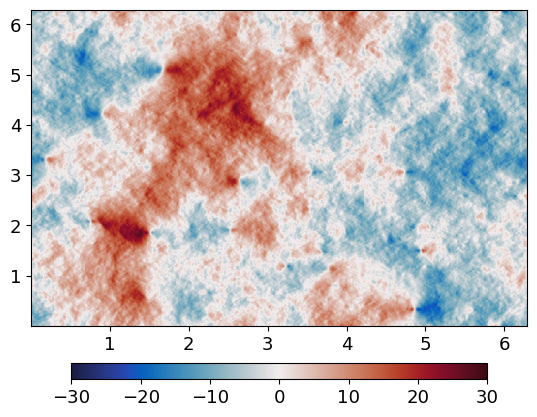

In [162]:
u1=u
from cmocean import cm
X,Y=np.meshgrid(x,y)
tin=100
cs2=plt.pcolormesh(X,Y,np.squeeze(v[tin,:,:]),cmap=cm.balance,vmin=-30,vmax=30)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

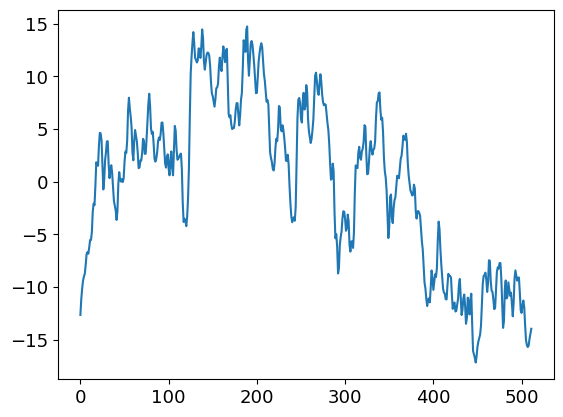

In [163]:
plt.plot(v[tin,256,:])
plt.show()

In [164]:
from scipy.signal import get_window
from scipy.fft import rfft2, irfft2

ur=v[tin,:,:]
Ny, Nx = ur.shape
    
# 1. 计算镜像扩展尺寸
pad_x = int(Nx * pad_ratio)
pad_y = int(Ny * pad_ratio)

# 2. 镜像扩展边界
ur_padded = np.pad(ur, ((pad_y, pad_y), (pad_x, pad_x)), mode='reflect')
Ny_pad, Nx_pad = ur_padded.shape

# 3. 在扩展数据上创建Tukey窗 (二维)
window_x = get_window(('tukey', 0.1), Nx_pad)
window_y = get_window(('tukey', 0.1), Ny_pad)
w = np.outer(window_y, window_x)

# 4. 加窗并FFT
u11 = rfft2(ur_padded * w)
ur_filtered_padded = irfft2(u11, s=(Ny_pad, Nx_pad))
ur_filtered = ur_filtered_padded[pad_y:pad_y+Ny, pad_x:pad_x+Nx]

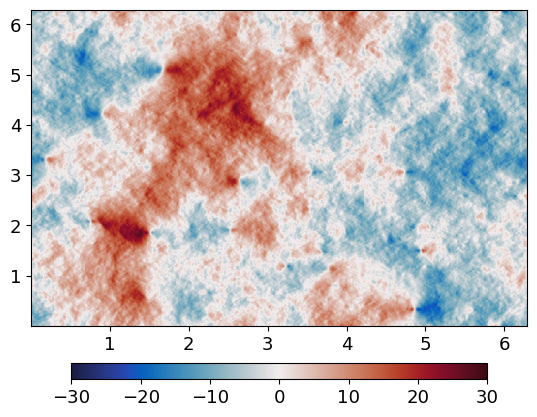

In [165]:
cs2=plt.pcolormesh(X,Y,ur_filtered,cmap=cm.balance,vmin=-30,vmax=30)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

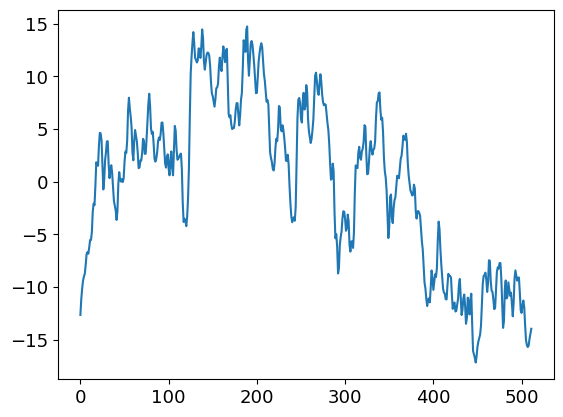

In [166]:
plt.plot(ur_filtered[256,:])
plt.show()

In [18]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

wind = 0  # no windowing
detr = 0  # no detrend

# Assuming eddyrun_lev is a preloaded xarray dataset
# un = u1.chunk({'time': 100, 'x': 256, 'y': 256})
# vn = v1.chunk({'time': 100, 'x': 256, 'y': 256})

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])

# flux = np.zeros((Nt, Nk))

# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

100%|█████████████████████████████████████████████████████████| 199/199 [00:01<00:00, 187.85it/s]


In [20]:
sio.savemat('HIT2d_fftfk.mat',{'K1D':K1D,'specFlux_mean':specFlux_mean,'specFlux_std':specFlux_std,
                               'divFlux_mean':divFlux_mean,'divFlux_std':divFlux_std})

# transform drifts

In [4]:
import scipy.io
import pickle

mat_data = scipy.io.loadmat('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/traj_mat_GLAD_15min_04_May_2021.mat')
print(mat_data.keys()) 
with open('traj_mat_GLAD_15min_04_May_2021.pkl', 'wb') as f:
    pickle.dump(mat_data, f)

mat_data = scipy.io.loadmat('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/traj_mat_LASER_15min_04_May_2021.mat')
print(mat_data.keys()) 
with open('traj_mat_LASER_15min_04_May_2021.pkl', 'wb') as f:
    pickle.dump(mat_data, f)

dict_keys(['__header__', '__version__', '__globals__', 'T_axis', 'trajmat_U', 'trajmat_V', 'trajmat_X', 'trajmat_Y'])
dict_keys(['__header__', '__version__', '__globals__', 'T_axis', 'trajmat_U', 'trajmat_V', 'trajmat_X', 'trajmat_Y'])


In [6]:
import mat73
import pickle

# 文件路径
file_path = '/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/pairs_sep_GLAD.mat'

# 加载 MATLAB v7.3 文件
data = mat73.loadmat(file_path)

# 打印所有键（变量名）
print("文件中的变量:", list(data.keys()))

# 保存为 PKL 文件
with open('pairs_sep_GLAD.pkl', 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("文件已成功保存为 pairs_sep_GLAD.pkl")

文件中的变量: ['dist_axis', 'pairs_sep']
文件已成功保存为 pairs_sep_GLAD.pkl


In [7]:
import mat73
import pickle

# 文件路径
file_path = '/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/pairs_sep_LASER.mat'

# 加载 MATLAB v7.3 文件
data = mat73.loadmat(file_path)

# 打印所有键（变量名）
print("文件中的变量:", list(data.keys()))

# 保存为 PKL 文件
with open('pairs_sep_LASER.pkl', 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("文件已成功保存为 pairs_sep_LASER.pkl")

文件中的变量: ['dist_axis', 'pairs_sep']
文件已成功保存为 pairs_sep_LASER.pkl


# calc fft-specflux Iceland

In [64]:
outpur_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_wave'


grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'

os.chdir(grid_dir)
grid=xr.open_dataset('niskin2km_500m_grd.nc')

os.chdir(outpur_dir)
dataw=xr.open_dataset('z_niskin2km_his_hf_depth_500m_grd.0002.nc')

dsw = xr.merge([dataw,grid])
print(dsw)
print('\n data size: %.1f GB' %(dsw.nbytes / 1e9))

# nowave
outpur_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave'

grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'

os.chdir(grid_dir)
grid=xr.open_dataset('niskin2km_500m_grd.nc')

os.chdir(outpur_dir)
datanw=xr.open_dataset('z_niskin2km_his_smooth_depth_500m_grd.0002.nc')
dsnw = xr.merge([datanw,grid])
print(dsnw)
print('\n data size: %.1f GB' %(dsnw.nbytes / 1e9))


os.chdir('/meddy/simingzhang/Data/RB_iceland_data/')

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287, one: 1, bath: 1, eta_u: 287, xi_v: 287,
                 eta_psi: 286, xi_psi: 286)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho, one, bath,
                                eta_u, xi_v, eta_psi, xi_psi
Data variables: (12/38)
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    xl          (one) float64 8B ...
    el          (one) float64 8B ...
    ...          ...
    lat_v       (eta_v, xi_v) float64 657kB ...
    lat_psi     (eta_psi, xi_psi) float64 654kB ...
    mask_rho    (eta_rho, xi_rho) float64 659kB ...
    mask_u      (eta_u, xi_u) float64 657kB ...
    mask_v      (eta_v, xi_v) float64 657

In [65]:
dsw

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287, one: 1, bath: 1, eta_u: 287, xi_v: 287,
                 eta_psi: 286, xi_psi: 286)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho, one, bath,
                                eta_u, xi_v, eta_psi, xi_psi
Data variables: (12/38)
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    xl          (one) float64 8B ...
    el          (one) float64 8B ...
    ...          ...
    lat_v       (eta_v, xi_v) float64 657kB ...
    lat_psi     (eta_psi, xi_psi) float64 654kB ...
    mask_rho    (eta_rho, xi_rho) float64 659kB ...
    mask_u      (eta_u, xi_u) float64 657kB ...
    mask_v      (eta_v, xi_v) float64 657kB ...
    mask_psi    (eta_psi, xi_psi) float64 654kB ...
Attributes:
    history:                   Thu Jul 18 14:58:06 2019: ncrcat -d depth,0 z_...
    nco_openmp_thread_number:  1

In [86]:
Case='nowave'
if Case=='wave':
    un=u2rho_3d(np.squeeze(dsw['u'].values))
    vn=v2rho_3d(np.squeeze(dsw['v'].values))
if Case=='nowave':
    un=u2rho_3d(np.squeeze(dsnw['u'].values))
    vn=v2rho_3d(np.squeeze(dsnw['v'].values))
xs=np.mean([1/grid['pm'].values,1/grid['pn'].values])

x=(np.arange(287)+1)*xs
y=x

In [87]:
un.shape

(2148, 287, 287)

In [88]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

wind = 1  # no windowing
detr = 0  # no detrend

# Assuming eddyrun_lev is a preloaded xarray dataset
# un = u1.chunk({'time': 100, 'x': 256, 'y': 256})
# vn = v1.chunk({'time': 100, 'x': 256, 'y': 256})

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])

# flux = np.zeros((Nt, Nk))

# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

  0%|          | 0/2148 [00:00<?, ?it/s]

In [89]:
import scipy.io as sio
sio.savemat(f'{Case}_fftspec.mat',{'K1D':K1D,'specFlux_mean':specFlux_mean,'specFlux_std':specFlux_std,
                               'divFlux_mean':divFlux_mean,'divFlux_std':divFlux_std})
Case

'nowave'

In [90]:
os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')

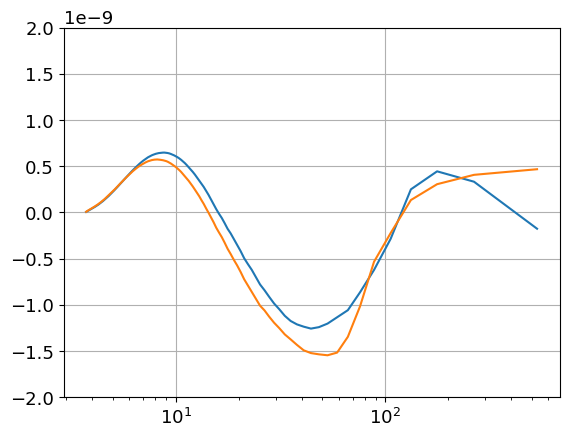

In [92]:
data=sio.loadmat('wave_fftspec.mat')
specFlux_mean=data['specFlux_mean'][0,:]
K1D=data['K1D'][0,:]
plt.semilogx(1/K1D/1e3,specFlux_mean)
data=sio.loadmat('nowave_fftspec.mat')
specFlux_mean=data['specFlux_mean'][0,:]
plt.semilogx(1/K1D/1e3,specFlux_mean)
plt.ylim([-2e-9,2e-9])
plt.grid(True)
plt.show()

# check cg using xscale
### spatial_cg_RB

# check cg_sfilt_mirror

In [277]:
# s2sflux_spec_all_hf.0002.nc
input_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='s2sflux_spec.0002.nc'
ds=xr.open_dataset(f'{input_dir}{fname}')
filtscale=ds['filtscale']
Thm=ds['Thm']

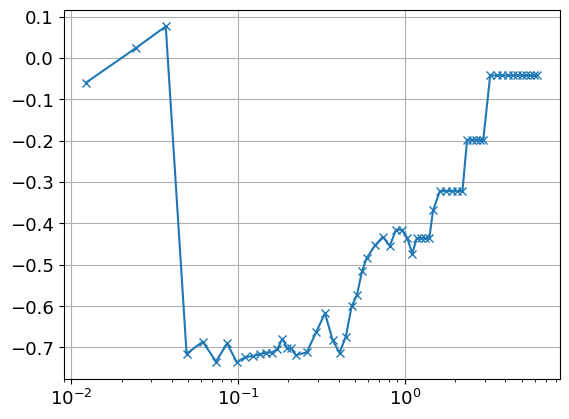

In [278]:
plt.semilogx(filtscale,Thm,marker='x')
plt.grid(True)
# plt.ylim([25e-8,2e-8])

plt.show()

In [260]:
filtscale

<xarray.DataArray 'filtscale' (filtscale: 61)> Size: 244B
array([0.012272, 0.024544, 0.036816, 0.049088, 0.061359, 0.073631, 0.085903,
       0.098175, 0.110447, 0.122719, 0.134991, 0.147263, 0.159534, 0.171806,
       0.184078, 0.19635 , 0.208622, 0.220894, 0.257709, 0.294525, 0.331341,
       0.368156, 0.404972, 0.441788, 0.478603, 0.515419, 0.552234, 0.58905 ,
       0.662681, 0.736313, 0.809944, 0.883575, 0.957206, 1.030838, 1.104469,
       1.1781  , 1.251731, 1.325363, 1.398994, 1.472625, 1.619888, 1.76715 ,
       1.914413, 2.061675, 2.208938, 2.3562  , 2.503463, 2.650725, 2.797988,
       2.94525 , 3.239775, 3.5343  , 3.828825, 4.12335 , 4.417875, 4.7124  ,
       5.006925, 5.30145 , 5.595975, 5.8905  , 6.185025], dtype=float32)
Coordinates:
  * filtscale  (filtscale) float32 244B 0.01227 0.02454 0.03682 ... 5.891 6.185

In [261]:
# fname='s2sflux_spec_all_hf.0002.nc'
fname='s2sflux_spec_all_hit.0002.nc'

ds=xr.open_dataset(f'{input_dir}{fname}')
Th2=np.squeeze(ds['Th2'].values[100,:,:,:])
# lonr=grid['lon_rho'].values
# latr=grid['lat_rho'].values

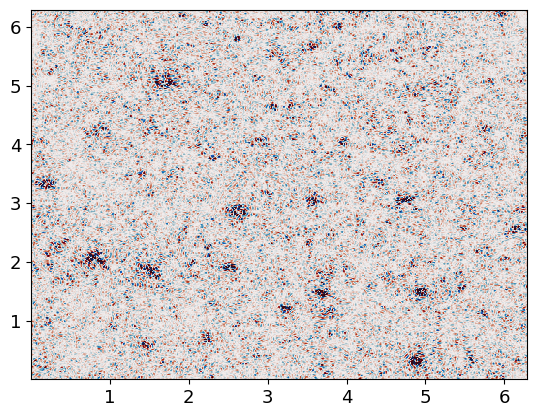

In [262]:
from cmocean import cm
# plt.pcolormesh(X,Y,Th2,cmap=cm.balance,vmin=-5e-7,vmax=5e-7)
cs2=plt.pcolormesh(X,Y,Th2,cmap=cm.balance,vmin=-800,vmax=800)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

In [263]:
ds

<xarray.Dataset> Size: 13GB
Dimensions:  (time: 199, depth: 1, eta_rho: 512, xi_rho: 512)
Dimensions without coordinates: time, depth, eta_rho, xi_rho
Data variables: (12/61)
    Th1      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th2      (time, depth, eta_rho, xi_rho) float32 209MB 143.7 51.11 ... -22.9
    Th3      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th4      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th5      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th6      (time, depth, eta_rho, xi_rho) float32 209MB ...
    ...       ...
    Th384    (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th408    (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th432    (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th456    (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th480    (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th504    (time, depth, eta_rho, xi_rho) float32 209MB ...

In [264]:
Narray = list(range(1,18))
Narray.extend(list(range(18,int(48),int(3))))
Narray.extend(list(range(48,int(120),int(6))))
Narray.extend(list(range(120,int(240),int(12))))
Narray.extend(list(range(240,int(520),int(24))))
Thm=np.zeros((199,len(Narray)))
for ii in range(len(Narray)):
    var=f'Th{Narray[ii]}'
    print(var)
    Thm[:,ii]=np.squeeze(np.nanmean(ds[var].values,axis=(2,3)))

Th1
Th2
Th3
Th4
Th5
Th6
Th7
Th8
Th9
Th10
Th11
Th12
Th13
Th14
Th15
Th16
Th17
Th18
Th21
Th24
Th27
Th30
Th33
Th36
Th39
Th42
Th45
Th48
Th54
Th60
Th66
Th72
Th78
Th84
Th90
Th96
Th102
Th108
Th114
Th120
Th132
Th144
Th156
Th168
Th180
Th192
Th204
Th216
Th228
Th240
Th264
Th288
Th312
Th336
Th360
Th384
Th408
Th432
Th456
Th480
Th504


In [265]:
np.nanmean(ds[var].values,axis=(2,3)).shape

(199, 1)

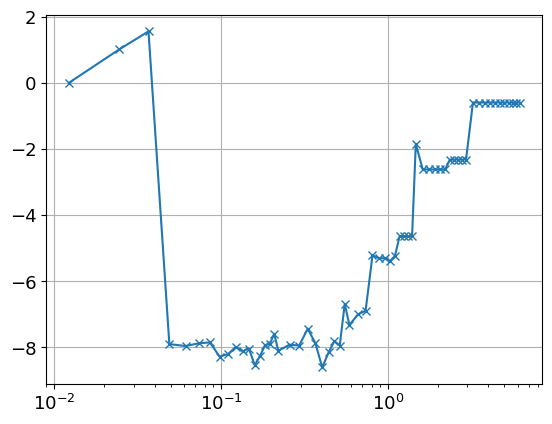

In [266]:
# for ii in range(Thm.shape[0]):
    # plt.semilogx(filtscale,Thm[ii,:],marker='x')
plt.semilogx(filtscale,np.nanmean(Thm,axis=0),marker='x')
plt.grid(True)
# plt.ylim([25e-8,2e-8])

plt.show()

In [273]:
from scipy.signal import get_window
window_x = get_window(('kaiser', 14), 10)
window_y = np.ones((10))
window_x = np.ones((10))

window_y.shape

(10,)

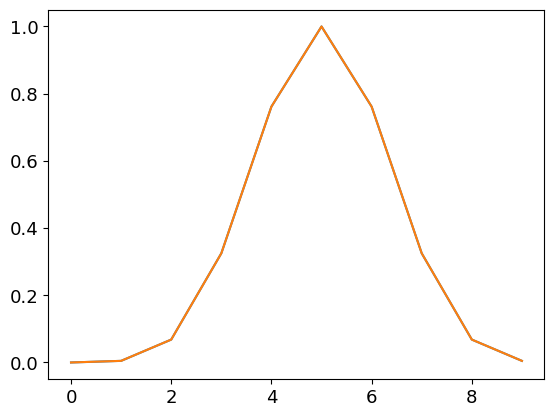

In [270]:
plt.plot(window_x)
plt.show()